In [30]:
import pandas as pd
from pathlib import Path
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [31]:
df = pd.read_csv("nse_final.csv")

In [32]:
df

,tradedate,open,high,low,close,previous,traded_volume,traded_value,num_trades,mcap,fid,gics_sector,in_NSE500,cap_classification,tradeprice
0,2009-12-31,243.72,246.42,243.12,245.19,NaN,4009836,4.371860e+06,74386,356620.00,476,10.0,True,largecap,244.6125
1,2009-12-31,196.33,197.33,195.53,196.33,NaN,727549,8.571160e+05,12436,251959.00,6068,10.0,True,largecap,196.3800
2,2009-12-31,196.04,201.12,194.00,196.37,NaN,13812005,3.271630e+06,58302,194304.00,12001,55.0,True,largecap,196.8825
3,2009-12-31,101.09,101.19,99.03,99.63,NaN,114198,4.855120e+04,3333,167965.00,12059,15.0,True,largecap,100.2350
4,2009-12-31,323.13,326.75,323.13,325.14,NaN,1156906,3.007890e+06,18332,149183.00,2806,45.0,True,largecap,324.5375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1843146,2020-01-01,0.30,0.30,0.25,0.30,NaN,34193,9.033300e+00,25,9.51,35743,20.0,False,smallcap,0.2875
1843147,2020-01-01,6.30,6.85,6.30,6.50,NaN,192,1.286800e+00,4,8.68,40517,40.0,False,smallcap,6.4875
1843148,2020-01-01,0.45,0.50,0.45,0.50,NaN,12902,6.030950e+00,12,6.25,4702,15.0,False,smallcap,0.4750
1843149,2020-01-01,0.10,0.10,0.05,0.10,NaN,289349,2.029450e+01,52,6.01,28304,20.0,False,smallcap,0.0875


In [66]:
'''prices = df.pivot(index = "tradedate", columns = "fid", values = "tradeprice")
mcaps = df.pivot(index = "tradedate", columns = "fid", values = "mcap")

prices = prices.ffill(limit_area='inside')
prices.index = pd.to_datetime(prices.index)

mcaps = mcaps.ffill(limit_area='inside')
mcaps.index = pd.to_datetime(mcaps.index)


sma_200 = prices.rolling(200).mean()

log_return = np.log(prices/prices.shift(1))
vol_6m = log_return.rolling(126).std()*np.sqrt(252)

prices = prices.iloc[200:]
mcaps = mcaps.iloc[200:]'''

In [67]:
'''dates = prices.resample("M").last().index
log = {}'''

In [68]:
'''for date in dates:
    if date not in prices.index:
        date = prices.index[prices.index <= date][-1]

    curr_mcap = mcaps.loc[date]
    top_200 = curr_mcap.nlargest(200).index

    curr_prices = prices.loc[date, top_200]
    curr_sma = sma_200.loc[date, top_200]
    
    is_up = curr_prices > curr_sma
    top_names = is_up[is_up].index
    
    if (len(top_names) > 0):
        curr_vol = vol_6m.loc[date, top_names]
        top_stocks = curr_vol.nsmallest(30)

        if not top_stocks.empty:
            inv_vol = 1.0/top_stocks
            weights = inv_vol/inv_vol.sum()
            log[date] = weights
        else:
            log[date] = pd.Series(dtype = float)
    else:
        log[date] = pd.Series(dtype = float)'''

In [72]:
import pandas as pd
import numpy as np

# 1. Load and Pivot
df = pd.read_csv("nse_final.csv")
df['tradedate'] = pd.to_datetime(df['tradedate']) # Force Datetime

prices = df.pivot(index="tradedate", columns="fid", values="tradeprice").ffill(limit_area='inside')
mcaps = df.pivot(index="tradedate", columns="fid", values="mcap").ffill(limit_area='inside')

# 2. Calculate Indicators on FULL Data (Before slicing!)
# Refinement: Use SMA 50 for faster trend detection (vs SMA 200)
sma_50 = prices.rolling(50).mean()

# Refinement: Use 3-Month Volatility (63 days) for quicker adaptation
log_rets = np.log(prices / prices.shift(1))
vol_3m = log_rets.rolling(63).std() * np.sqrt(252)

# 3. Define Trading Dates (Month Ends)
# We slice getting dates to start from 2011 to ensure enough warmup data exists
trading_dates = prices.resample('ME').last().index # Use 'ME' for month-end
trading_dates = trading_dates[trading_dates >= prices.index[200]] 

signal_log = {}

print("Generating Signals...")

for date in trading_dates:
    # Handle holidays: Find the closest valid trading day on or before month-end
    if date not in prices.index:
        lookup_date = prices.index[prices.index <= date][-1]
    else:
        lookup_date = date
        
    # --- Step A: Universe Selection ---
    # Top 200 Liquid Stocks by Market Cap
    if lookup_date not in mcaps.index: continue
    
    universe = mcaps.loc[lookup_date].nlargest(200).index
    
    # --- Step B: Trend Filter ---
    # Stock must be above its 50-day average
    curr_prices = prices.loc[lookup_date, universe]
    curr_sma = sma_50.loc[lookup_date, universe]
    
    uptrend_stocks = curr_prices[curr_prices > curr_sma].index
    
    # --- Step C: Low Volatility Selection ---
    if len(uptrend_stocks) > 0:
        # Get Volatility for uptrend stocks
        curr_vols = vol_3m.loc[lookup_date, uptrend_stocks].dropna()
        
        # Pick Top 30 Lowest Volatility
        selected_stocks = curr_vols.nsmallest(30)
        
        # --- Step D: Weighting (Inverse Volatility) ---
        if not selected_stocks.empty:
            inv_vol = 1.0 / selected_stocks
            weights = inv_vol / inv_vol.sum()
            
            # Save signal using the LOOKUP DATE to match backtester keys exactly
            signal_log[lookup_date] = weights

Generating Signals...


In [69]:
'''def backtest_strategy(df, signal_log, initial_capital=5000000):
    print("Initializing Backtester...")
    
    df['tradedate'] = pd.to_datetime(df['tradedate'])
    
    df['exec_price'] = (df['open'] + df['high'] + df['low'] + df['close']) / 4.0
    
    exec_prices = df.pivot(index='tradedate', columns='fid', values='exec_price')
    exec_prices = exec_prices.ffill(limit_area='inside')
    
    all_dates = sorted(exec_prices.index)
    
    current_cash = initial_capital
    current_shares = {}
    
    history = []
    
    TX_COST = 0.00268 
    BUFFER = 0.005 

    print("Running day-by-day simulation...")
    
    pending_target_weights = None
    
    for i, date in enumerate(all_dates):
        stock_value = 0.0
        
        current_prices = exec_prices.loc[date]
        portfolio_composition = {}
        
        stocks_to_remove = []
        for symbol, qty in current_shares.items():
            if symbol in current_prices and not pd.isna(current_prices[symbol]):
                val = qty * current_prices[symbol]
                stock_value += val
                portfolio_composition[symbol] = val
            else:
                stocks_to_remove.append(symbol)
        
        for s in stocks_to_remove:
            del current_shares[s]

        total_portfolio_value = current_cash + stock_value
        
        # --- Signal Execution Logic ---
        if pending_target_weights is not None:
            today_exec_prices = exec_prices.loc[date]
            
            current_holdings_val = {sym: qty * today_exec_prices.get(sym, 0) 
                                    for sym, qty in current_shares.items()}
            
            all_involved_stocks = set(current_shares.keys()).union(pending_target_weights.index)
            
            for symbol in all_involved_stocks:
                target_pct = pending_target_weights.get(symbol, 0.0)
                target_val = total_portfolio_value * target_pct
                
                current_val = current_holdings_val.get(symbol, 0.0)
                price = today_exec_prices.get(symbol, np.nan)
                
                if pd.isna(price):
                    continue 
                
                deviation_val = target_val - current_val
                
                if abs(deviation_val) < (total_portfolio_value * BUFFER):
                    continue
                
                trade_val = deviation_val
                shares_to_trade = int(trade_val / price)
                
                if shares_to_trade == 0:
                    continue

                trade_cost = abs(shares_to_trade * price) * TX_COST
                
                if shares_to_trade < 0:
                    shares_to_sell = min(abs(shares_to_trade), current_shares.get(symbol, 0))
                    
                    gross_proceeds = shares_to_sell * price
                    net_proceeds = gross_proceeds - trade_cost
                    
                    current_cash += net_proceeds
                    current_shares[symbol] = current_shares.get(symbol, 0) - shares_to_sell
                    
                    if current_shares[symbol] == 0:
                        del current_shares[symbol]

            for symbol in all_involved_stocks:
                target_pct = pending_target_weights.get(symbol, 0.0)
                target_val = total_portfolio_value * target_pct
                current_val = current_shares.get(symbol, 0) * today_exec_prices.get(symbol, 0)
                
                deviation_val = target_val - current_val
                
                if abs(deviation_val) < (total_portfolio_value * BUFFER):
                    continue

                price = today_exec_prices.get(symbol, np.nan)
                if pd.isna(price): continue
                
                shares_to_trade = int(deviation_val / price)
                
                if shares_to_trade > 0:
                    cost_to_buy = (shares_to_trade * price)
                    total_cost = cost_to_buy + (cost_to_buy * TX_COST)
                    
                    if current_cash >= total_cost:
                        current_cash -= total_cost
                        current_shares[symbol] = current_shares.get(symbol, 0) + shares_to_trade
            
            pending_target_weights = None

        final_stock_val = 0.0
        for symbol, qty in current_shares.items():
             if symbol in current_prices and not pd.isna(current_prices[symbol]):
                 final_stock_val += qty * current_prices[symbol]
        
        post_trade_equity = current_cash + final_stock_val

        if date in signal_log:
            pending_target_weights = signal_log[date]
        
        history.append({
            'date': date,
            'Total_Equity': post_trade_equity,
            'Cash': current_cash,
            'Holdings_Count': len(current_shares)
        })

    res_df = pd.DataFrame(history)
    res_df.set_index('date', inplace=True)
    
    print("Backtest Complete.")
    return res_df'''

In [70]:
performance_df = backtest_strategy(df, log)

Initializing Backtester...
Running day-by-day simulation...
Backtest Complete.


<Axes: title={'center': 'Strategy Equity Curve'}, xlabel='date'>

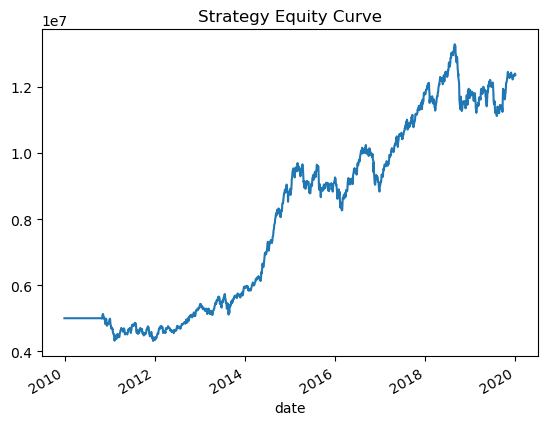

In [71]:
performance_df['Total_Equity'].plot(title="Strategy Equity Curve")

In [52]:
final_amount = performance_df.iloc[-1]["Total_Equity"]

In [55]:
cagr = ((final_amount/5000000)**(1/10))-1
print(cagr*100)

9.483929010760516
